<a href="https://colab.research.google.com/github/pranathi139/GenAI/blob/main/Week1_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install nltk wordcloud

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
nltk.download('stopwords')
nltk.download('punkt')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

import re
import string

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [ ]:

# Load only required columns from large dataset
df = pd.read_csv(
    "Reviews.csv",
    usecols=['Text', 'Score'],
    nrows=50000
)

df.head()


,Score,Text
0,5,I have bought several of the Vitality canned d...
1,1,Product arrived labeled as Jumbo Salted Peanut...
2,4,This is a confection that has been around a fe...
3,2,If you are looking for the secret ingredient i...
4,5,Great taffy at a great price. There was a wid...


In [ ]:
# Convert numeric review scores into sentiment labels

def label_sentiment(score):
    if score <= 2:
        return 'negative'
    elif score == 3:
        return 'neutral'
    else:
        return 'positive'

df['Sentiment'] = df['Score'].apply(label_sentiment)

# Keep only text and sentiment columns
df = df[['Text', 'Sentiment']]

df.head()

,Text,Sentiment
0,I have bought several of the Vitality canned d...,positive
1,Product arrived labeled as Jumbo Salted Peanut...,negative
2,This is a confection that has been around a fe...,positive
3,If you are looking for the secret ingredient i...,negative
4,Great taffy at a great price. There was a wid...,positive


In [ ]:
import nltk
nltk.download('punkt_tab')
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    return " ".join(tokens)

df['Clean_Text'] = df['Text'].apply(preprocess_text)

df[['Text', 'Clean_Text']].head()


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,Text,Clean_Text
0,I have bought several of the Vitality canned d...,bought several vitality canned dog food produc...
1,Product arrived labeled as Jumbo Salted Peanut...,product arrived labeled jumbo salted peanutsth...
2,This is a confection that has been around a fe...,confection around centuries light pillowy citr...
3,If you are looking for the secret ingredient i...,looking secret ingredient robitussin believe f...
4,Great taffy at a great price. There was a wid...,great taffy great price wide assortment yummy ...


In [ ]:
df.columns

Index(['Text', 'Sentiment', 'Clean_Text'], dtype='object')

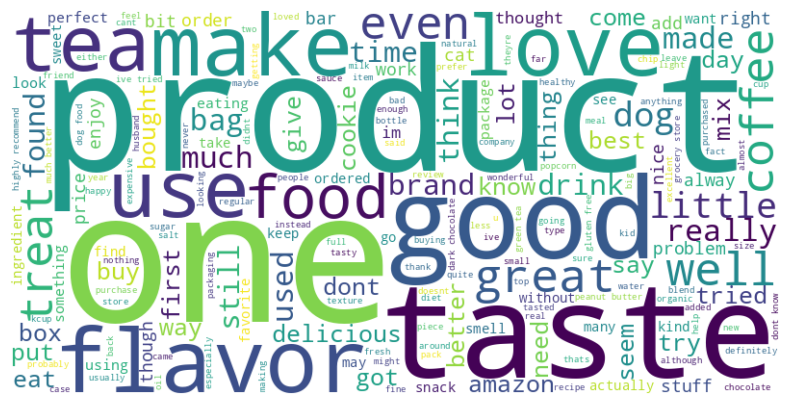

In [ ]:
from wordcloud import WordCloud

all_reviews = " ".join(df['Clean_Text'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(all_reviews)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

Step 2 Feature Extraction

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# Bag of Words
bow = CountVectorizer(max_features=5000)

X_bow = bow.fit_transform(df['Clean_Text'])
y = df['Sentiment']

X_bow.shape

(50000, 5000)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF feature extraction
tfidf = TfidfVectorizer(max_features=5000)

X_tfidf = tfidf.fit_transform(df['Clean_Text'])

X_tfidf.shape


(50000, 5000)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((40000, 5000), (10000, 5000))

Step 3 Model Building-Logistic Regression Model

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=200)
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

accuracy_score(y_test, y_pred)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.761875

In [ ]:
df_rnn = df.sample(8000, random_state=42)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(df_rnn['Clean_Text'])

X = pad_sequences(
    tokenizer.texts_to_sequences(df_rnn['Clean_Text']),
    maxlen=100
)

y = LabelEncoder().fit_transform(df_rnn['Sentiment'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

model = Sequential([
    Embedding(5000, 64),
    SimpleRNN(64),
    Dense(3, activation='softmax')
])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.fit(X_train, y_train, epochs=3)
model.evaluate(X_test, y_test)


Epoch 1/3
200/200 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accuracy: 0.7580 - loss: 0.7023
Epoch 2/3
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.8423 - loss: 0.4216
Epoch 3/3
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - accuracy: 0.9716 - loss: 0.1039
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7688 - loss: 0.7787


[0.7786574363708496, 0.768750011920929]

Step 4 Evaluation

50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
RNN Accuracy: 0.76875


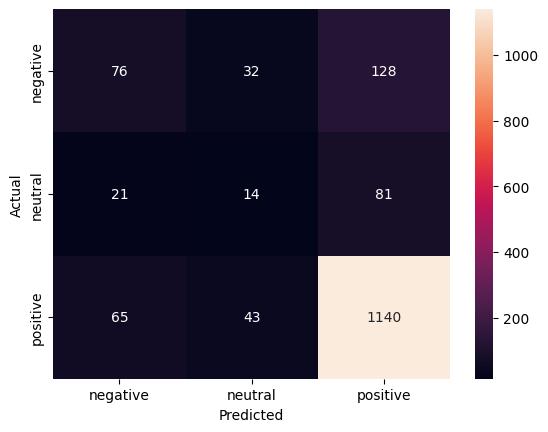

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predict
y_pred = model.predict(X_test).argmax(axis=1)

# Accuracy
print("RNN Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['negative','neutral','positive'],
            yticklabels=['negative','neutral','positive'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()